In [2]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START,END
from langchain_core.prompts import PromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [1]:
pip install -U langchain-text-splitters

  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.7
    Uninstalling langchain-core-1.2.7:
      Successfully uninstalled langchain-core-1.2.7
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 1.1.0
    Uninstalling langchain-text-splitters-1.1.0:
      Successfully uninstalled langchain-text-splitters-1.1.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough, RunnableParallel

In [5]:
import os
os.environ['OPENAI_API_KEY']="sk-

In [6]:
llm=ChatOpenAI()
embeddings=OpenAIEmbeddings()

In [7]:
from langchain_community.document_loaders import PyPDFLoader

In [96]:
doc=PyPDFLoader(r"C:\Users\ratha\OneDrive\Desktop\YOLOv3.pdf")

In [97]:
document=doc.load()

In [98]:
document="\n\n".join([d.page_content for d in document])

In [99]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
chunks=splitter.split_text(document)

In [100]:
len(chunks)

31

In [101]:

from langchain_core.documents import Document
chunks_as_docs = [Document(page_content=chunk) if isinstance(chunk, str) else chunk for chunk in chunks]
vector_store = FAISS.from_documents(chunks_as_docs, embeddings)
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 3})

In [102]:
from langchain_community.vectorstores import FAISS

In [103]:
retriever.invoke("Is someone by the name Soubhik discussed here?")[0].page_content

'References\n[1] Analogy. Wikipedia, Mar 2018. 1\n[2] M. Everingham, L. Van Gool, C. K. Williams, J. Winn, and\nA. Zisserman. The pascal visual object classes (voc) chal-\nlenge. International journal of computer vision, 88(2):303–\n338, 2010. 6\n[3] C.-Y . Fu, W. Liu, A. Ranga, A. Tyagi, and A. C. Berg.\nDssd: Deconvolutional single shot detector. arXiv preprint\narXiv:1701.06659, 2017. 3\n[4] D. Gordon, A. Kembhavi, M. Rastegari, J. Redmon, D. Fox,\nand A. Farhadi. Iqa: Visual question answering in interactive\nenvironments. arXiv preprint arXiv:1712.03316, 2017. 1\n[5] K. He, X. Zhang, S. Ren, and J. Sun. Deep residual learn-\ning for image recognition. In Proceedings of the IEEE con-\nference on computer vision and pattern recognition, pages\n770–778, 2016. 3\n[6] J. Huang, V . Rathod, C. Sun, M. Zhu, A. Korattikara,\nA. Fathi, I. Fischer, Z. Wojna, Y . Song, S. Guadarrama, et al.\nSpeed/accuracy trade-offs for modern convolutional object\ndetectors. 3'

In [104]:
from langchain_core.tools import tool

In [105]:
@tool
def rag_tool(query: str) -> str:
    """
    You are a helpful assistant that retrieves relevant information from a collection of documents based on the user's query. Use the retriever to find the most relevant document chunks and return their content as the answer to the user's query.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata

    }
   

In [106]:
llm_with_tools = llm.bind_tools([rag_tool])

In [107]:
from langgraph.prebuilt import ToolNode

In [108]:
tools=[rag_tool]

In [109]:
tool_node=ToolNode(tools)

In [124]:
from typing import TypedDict,Annotated
from langgraph.graph.message import BaseMessage,add_messages
from langchain_core.messages import HumanMessage,AIMessage

In [111]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [112]:
def chat_node(state:ChatState)->ChatState:
    response=llm_with_tools.invoke(state['messages'])
    state['messages'].append(response)
    return state

In [145]:
def tool_condition(state:ChatState):
    last_message=state['messages'][-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return 'tool_node'
    else:
        return END

In [146]:
graph=StateGraph(ChatState)

In [147]:
graph.add_node('chat_node',chat_node)
graph.add_node('tool_node',tool_node)

In [148]:
graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tool_condition)
graph.add_edge('tool_node','chat_node')


In [149]:
workflow=graph.compile()

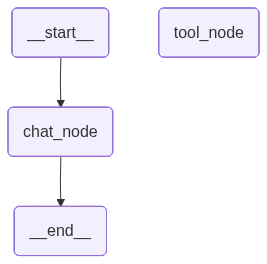

In [150]:
workflow

In [153]:
result = workflow.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "What are the different improvements that are discussed about yolov3 in thsi document? Give 5 bullet points"
                )
            )
        ]
    }
)

In [154]:
print(result['messages'][-1].content)

Here are 5 bullet points discussing the different improvements made to YOLOv3:
- Little design changes were made to make YOLOv3 better.
- A new network was trained that is more accurate and faster.
- YOLOv3 runs at 22 ms at 28.2 mAP, as accurate as SSD but three times faster.
- YOLOv3 achieves 57.9 AP50 in 51 ms on a Titan X, compared to 57.5 AP50 in 198 ms by RetinaNet, similar performance but 3.8× faster.
- YOLOv3 excels at producing decent boxes for objects and has improved performance on small objects with new multi-scale predictions.
